In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

In [2]:
from src.transforms import trainval_transforms, revert_normalization, revert_standardization
from src.dataset import ImageDataset
import torch

annot_path = Path("../data/preprocessed/trainval/annotations.csv")
img_dir = Path("../data/preprocessed/trainval/images")

# test dataset without transforms
dataset = ImageDataset(annot_path, img_dir, transform=trainval_transforms)

In [3]:
image, targets = next(iter(dataset))
obj_coords = []
obj_coords_tensors = []

In [4]:
revert_standardization(image)
image = revert_normalization(image)

In [5]:
from src.utilities import convert_xywh_coordinates

for i in range(7):
    for j in range(7):
        coord = targets[i][j][20:24]
        
        if torch.any(coord):
            obj_coords.append(
                convert_xywh_coordinates(coord, i, j, True)
            )
            obj_coords_tensors.append(
                convert_xywh_coordinates(coord, i, j, False)
            )

In [6]:
obj_coords

[(124, 111, 140, 131),
 (108, 116, 132, 178),
 (2, 146, 30, 224),
 (74, 158, 114, 222),
 (118, 126, 144, 202)]

In [7]:
obj_coords_tensors

[(tensor(124.), tensor(111.), tensor(140.), tensor(131.)),
 (tensor(108.), tensor(115.5000), tensor(132.), tensor(178.5000)),
 (tensor(2.), tensor(146.), tensor(30.), tensor(224.)),
 (tensor(74.5000), tensor(157.5000), tensor(113.5000), tensor(222.5000)),
 (tensor(117.5000), tensor(126.), tensor(144.5000), tensor(202.))]

In [8]:
labels = ["1", "2", "3", "4", "5"]

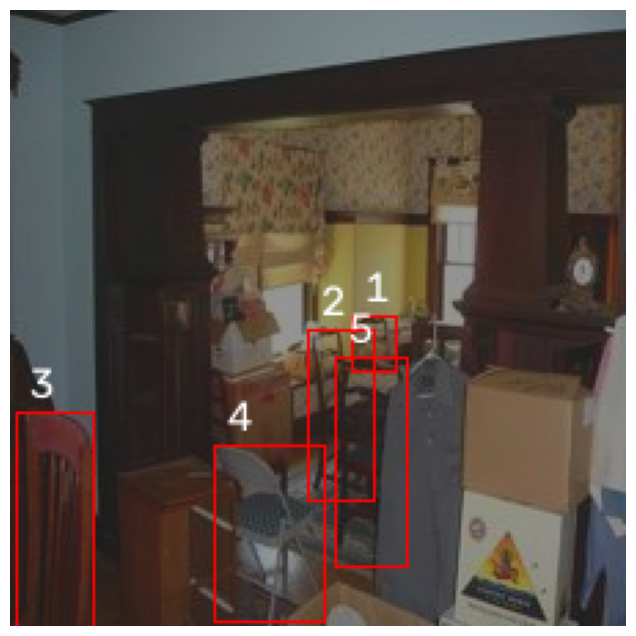

In [9]:
from matplotlib import pyplot as plt
from src.visualization import draw_rectangles

fig, ax = plt.subplots(1, figsize=(8, 8))

image = draw_rectangles(image, obj_coords, labels)

ax.imshow(image)
ax.axis(False)

plt.show()

In [10]:
from src.utilities import IoU

# Test first on completely matched boxes
IoU_1 = IoU(obj_coords_tensors[1], obj_coords_tensors[1])

# Test second on completely unmatched boxes
IoU_2 = IoU(obj_coords_tensors[2], obj_coords_tensors[3])

# Test third on slightly matched boxes
IoU_3 = IoU(obj_coords_tensors[4], obj_coords_tensors[0])
IoU_4 = IoU(obj_coords_tensors[4], obj_coords_tensors[1])
IoU_5 = IoU(obj_coords_tensors[4], obj_coords_tensors[2])
IoU_6 = IoU(obj_coords_tensors[4], obj_coords_tensors[3])

print(IoU_1, IoU_2, IoU_3, IoU_4, IoU_5, IoU_6)

tensor(1.) tensor(0.) tensor(0.0349) tensor(0.2716) tensor(0.) tensor(0.)


In [11]:
from src.utilities import objects_in_target

print(targets.shape, targets)

objects = objects_in_target(targets)
objects

torch.Size([7, 7, 25]) tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  

{'chair': [tensor([0.1250, 0.7812, 0.0714, 0.0893]),
  tensor([0.7500, 0.5938, 0.1071, 0.2812]),
  tensor([0.5000, 0.7812, 0.1250, 0.3482]),
  tensor([0.9375, 0.9375, 0.1741, 0.2902]),
  tensor([0.0938, 0.1250, 0.1205, 0.3393])]}